# Кластеризация сцинтилляционных сигналов для разделения гамма-квантов, нейтронов и аномальных событий

**Выполнила:** Чувиль Алина Германовна

## Цель проекта

Цель работы — построить воспроизводимое решение задачи машинного обучения без учителя для кластеризации сигналов сцинтилляционного детектора на три группы:

- сигналы первого типа частиц;
- сигналы второго типа частиц;
- аномальные или неидентифицируемые сигналы.

## Описание данных

В работе используется файл `Run200_Wave_0_1.txt`, содержащий 23 479 зарегистрированных сигналов. Каждый объект описан 504 признаками. Первые несколько признаков похожи на служебные параметры регистрации, а остальные признаки представляют собой временные отсчёты формы импульса.

## План работы

1. Импорт библиотек.
2. Загрузка и первичное изучение данных.
3. Разведочный анализ данных.
4. Предобработка данных.
5. Feature Engineering.
6. Снижение размерности.
7. Базовые модели кластеризации.
8. Продвинутые модели кластеризации.
9. Подбор гиперпараметров.
10. Выбор лучшей модели и интерпретация кластеров.
11. Формирование Kaggle Submission.
12. Анализ результата Kaggle.


### Kaggle score  

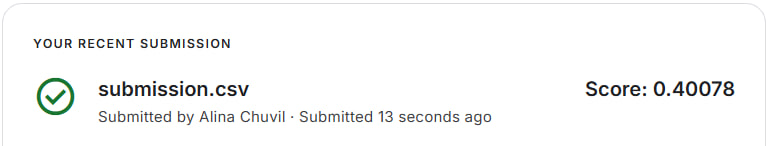

## Шаг 1. Импорт библиотек

На этом этапе подключаются библиотеки для анализа данных, визуализации, предобработки, снижения размерности и кластеризации.


In [5]:
import warnings
from itertools import permutations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kurtosis, skew
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_PATH = Path("Run200_Wave_0_1.txt")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")


## Шаг 2. Загрузка и первичное изучение данных

Загрузим данные и проверим размерность таблицы. Ожидается, что каждая строка соответствует одному зарегистрированному сигналу.


In [6]:
DATA_PATH = "/content/Run200_Wave_0_1.txt"

df = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
)

df.shape


(23479, 504)

In [7]:
df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,...,14820,14820,14819,14821,14827,14823,14817,14825,14824,14824,14815,14816,14817,14825,14817,14818,14823,14821,14824,14821,14824,14815,14817,14823,14820,14816,14818,14824,14815,14820,14818,14818,14818,14816,14824,14822,14823,14816,14818,14823,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,14823,14823,14822,14824,14827,14824,14822,14823,14823,14824,14824,14820,14824,14823,14822,14818,14828,14819,14824,14823,14820,14821,14822,14817,14824,14821,14823,14822,14819,14825,14824,14822,14827,14820,14820,14828,...,14824,14822,14820,14822,14819,14822,14820,14822,14820,14817,14818,14820,14824,14816,14819,14828,14820,14821,14824,14817,14818,14819,14820,14820,14822,14826,14824,14815,14819,14820,14820,14821,14819,14825,14822,14819,14824,14827,14817,14824,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,14823,14823,14823,14824,14819,14820,14823,14821,14820,14822,14818,14819,14820,14824,14822,14822,14820,14820,14824,14822,14820,14822,14823,14823,14822,14815,14820,14824,14827,14827,14823,14824,14820,14825,14820,14825,...,14824,14822,14820,14820,14818,14818,14817,14814,14823,14818,14819,14818,14824,14821,14820,14819,14824,14825,14818,14820,14820,14816,14815,14821,14820,14827,14819,14819,14824,14821,14819,14822,14822,14820,14820,14822,14822,14826,14823,14822,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,14820,14824,14826,14821,14818,14826,14820,14824,14824,14822,14823,14820,14819,14820,14820,14823,14820,14824,14823,14820,14823,14825,14827,14822,14818,14828,14824,14828,14820,14822,14824,14822,14828,14824,14820,14822,...,14820,14829,14823,14824,14820,14823,14819,14821,14823,14822,14822,14820,14817,14827,14819,14826,14824,14823,14823,14822,14824,14823,14823,14823,14820,14821,14823,14822,14824,14822,14820,14820,14820,14825,14820,14822,14823,14821,14824,14824,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,14822,14825,14822,14823,14820,14823,14823,14821,14820,14826,14820,14818,14819,14821,14822,14825,14820,14823,14823,14817,14823,14827,14823,14820,14817,14823,14828,14818,14823,14825,14820,14817,14819,14823,14824,14820,...,14822,14823,14823,14824,14819,14819,14820,14820,14819,14819,14820,14816,14819,14824,14819,14819,14820,14820,14823,14819,14820,14822,14823,14822,14817,14821,14820,14821,14817,14824,14820,14817,14820,14817,14823,14823,14820,14823,14820,14819,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


### Вывод по шагу 2

Данные успешно загружены. Датасет содержит 23 479 объектов и 504 признака. По первым строкам видно, что первые столбцы отличаются по масштабу от основной части признаков, а начиная примерно с 4-го столбца значения соответствуют отсчётам формы сигнала. Это подтверждает необходимость отдельного анализа служебных признаков и временной формы импульса.


## Шаг 3. Исследовательский анализ данных (EDA)

На этапе EDA проверяются качество данных, статистические свойства признаков и физическая структура сигналов.


In [8]:
missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

pd.DataFrame(
    {
        "metric": ["missing_values", "duplicate_rows"],
        "value": [missing_values, duplicate_rows],
    }
)


,metric,value
0,missing_values,0
1,duplicate_rows,0


In [9]:
stats_df = df.describe().T
stats_df[["mean", "std", "min", "25%", "50%", "75%", "max"]].head(20)


,mean,std,min,25%,50%,75%,max
0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
1,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
2,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
3,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
4,1.482297e+04,2.805884e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483400e+04
5,1.482296e+04,2.833516e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483500e+04
6,1.482297e+04,2.840755e+00,14812.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483400e+04
7,1.482299e+04,2.852066e+00,14811.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483500e+04
8,1.482300e+04,2.833412e+00,14812.0,1.482100e+04,1.482300e+04,1.482500e+04,1.483400e+04
9,1.482298e+04,2.836271e+00,14812.0,1.482100e+04,1.482300e+04,1.482400e+04,1.483500e+04


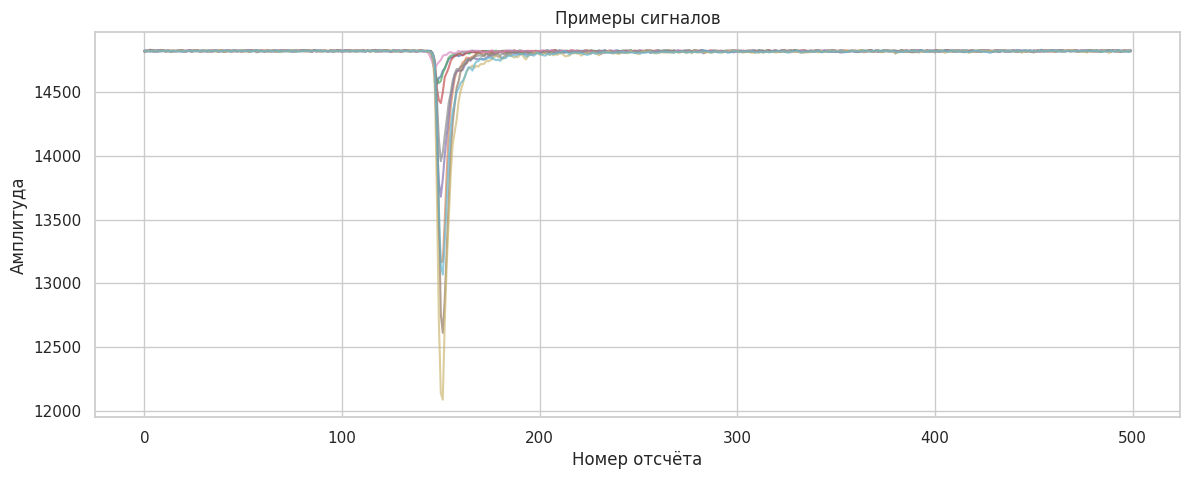

In [10]:
signal_columns = df.columns[4:]

plt.figure(figsize=(14, 5))

sample_indices = np.random.default_rng(RANDOM_STATE).choice(
    df.index,
    size=10,
    replace=False,
)

for idx in sample_indices:
    plt.plot(df.loc[idx, signal_columns].values, alpha=0.7)

plt.title("Примеры сигналов")
plt.xlabel("Номер отсчёта")
plt.ylabel("Амплитуда")
plt.show()


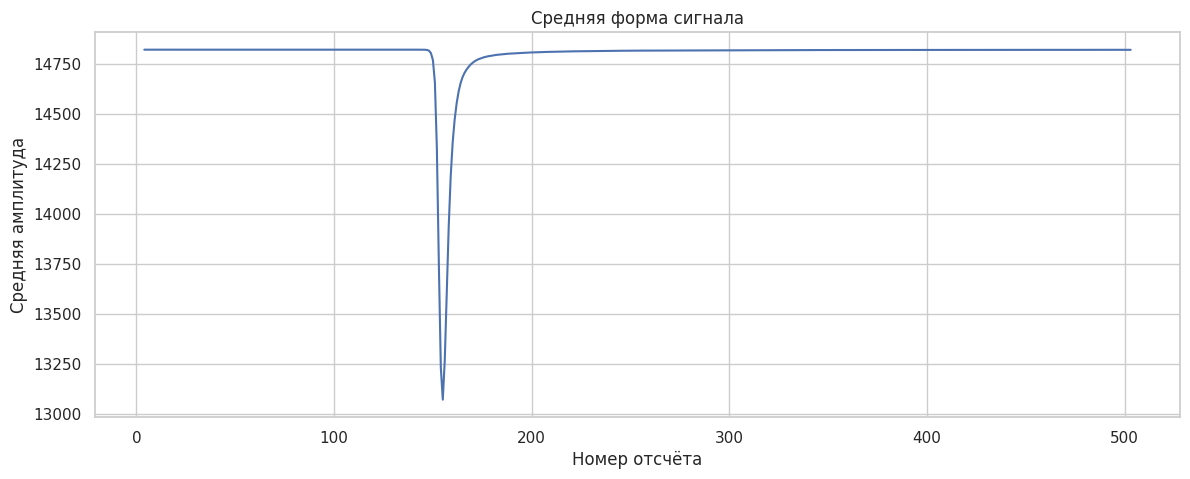

In [11]:
mean_signal = df[signal_columns].mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(mean_signal)
plt.title("Средняя форма сигнала")
plt.xlabel("Номер отсчёта")
plt.ylabel("Средняя амплитуда")
plt.show()


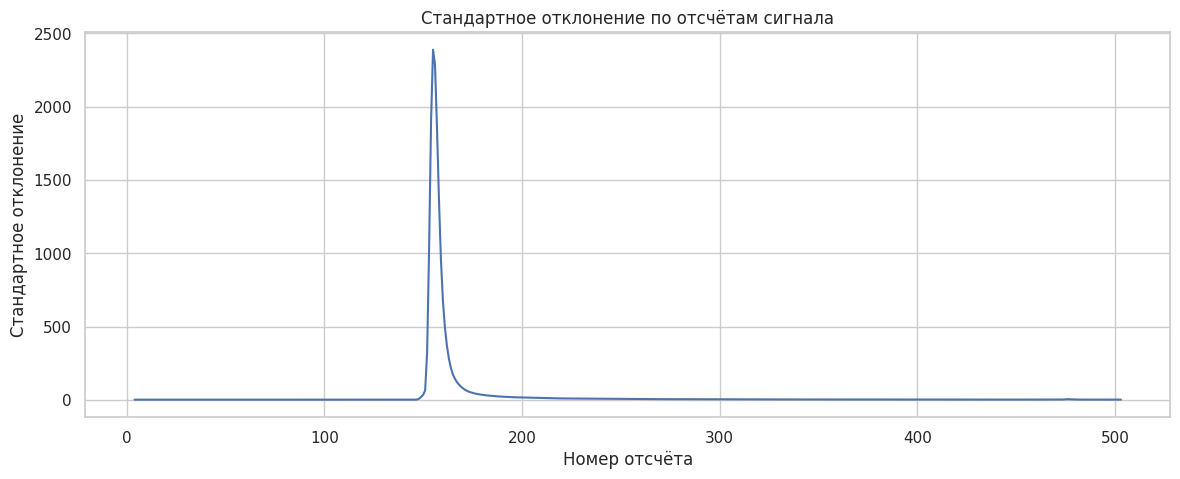

In [12]:
signal_std = df[signal_columns].std(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(signal_std)
plt.title("Стандартное отклонение по отсчётам сигнала")
plt.xlabel("Номер отсчёта")
plt.ylabel("Стандартное отклонение")
plt.show()


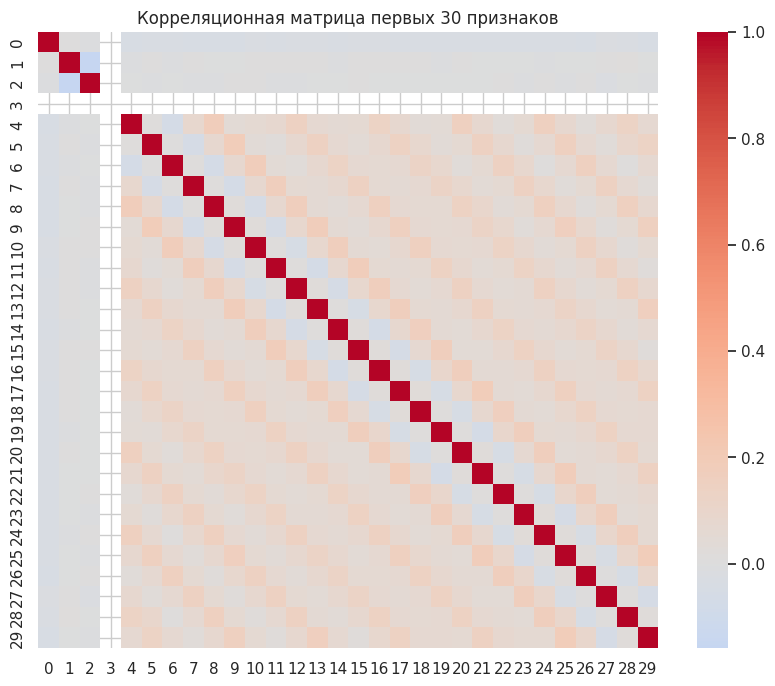

In [13]:
corr_matrix = df.iloc[:, :30].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
)
plt.title("Корреляционная матрица первых 30 признаков")
plt.show()


### Вывод по шагу 3

Пропуски и полные дубликаты в данных отсутствуют, поэтому восстановление значений и удаление повторов не требуется. Визуализация сигналов показывает характерную форму сцинтилляционного импульса: стабильная базовая линия, резкий провал и последующее восстановление. Средний сигнал подтверждает, что импульсы в основном синхронизированы по времени и возникают примерно в одной области окна наблюдения.

Наибольшая изменчивость наблюдается в зоне формирования импульса. Это означает, что именно центральная часть сигнала содержит основную информацию для разделения типов событий. Корреляционная матрица показывает зависимость между соседними отсчётами, что подтверждает избыточность исходного пространства признаков и обосновывает дальнейшее применение Feature Engineering и PCA.


## Шаг 4. Предобработка данных

На этом этапе разделим служебные признаки и форму сигнала, удалим константные признаки и подготовим масштабированные матрицы для дальнейшего анализа.


In [14]:
service_columns = df.columns[:4]
signal_columns = df.columns[4:]

service_df = df[service_columns].copy()
signals_df = df[signal_columns].copy()

pd.DataFrame(
    {
        "part": ["service_features", "signal_samples"],
        "rows": [service_df.shape[0], signals_df.shape[0]],
        "columns": [service_df.shape[1], signals_df.shape[1]],
    }
)


,part,rows,columns
0,service_features,23479,4
1,signal_samples,23479,500


In [15]:
constant_columns = df.columns[df.nunique() <= 1].tolist()

df_clean = df.drop(columns=constant_columns)

pd.DataFrame(
    {
        "stage": ["before", "after"],
        "rows": [df.shape[0], df_clean.shape[0]],
        "columns": [df.shape[1], df_clean.shape[1]],
    }
)


,stage,rows,columns
0,before,23479,504
1,after,23479,503


In [16]:
clean_variance = df_clean.var(axis=0)
clean_variance.describe()


,0
count,5.030000e+02
mean,6.494357e+18
std,1.456532e+20
min,7.823302e+00
25%,8.068926e+00
50%,1.542082e+01
75%,3.986663e+01
max,3.266662e+21


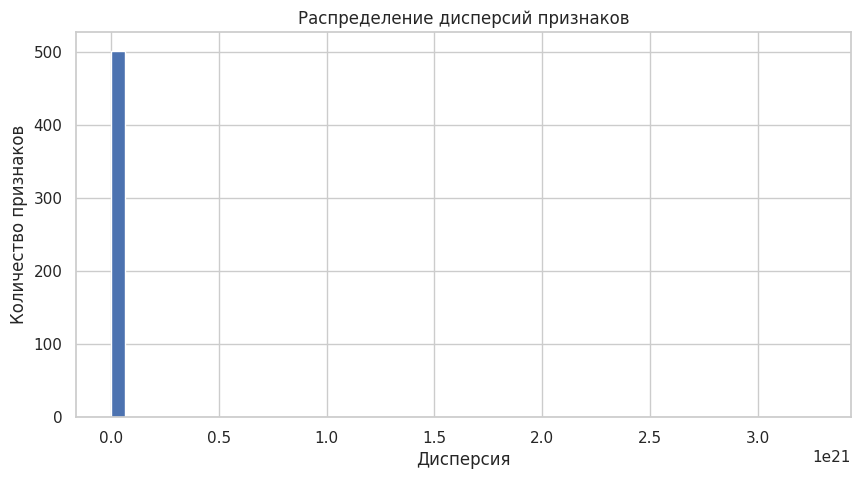

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(clean_variance, bins=50)
plt.title("Распределение дисперсий признаков")
plt.xlabel("Дисперсия")
plt.ylabel("Количество признаков")
plt.show()


In [18]:
scaler = RobustScaler()
x_scaled = scaler.fit_transform(df_clean)

x_scaled_df = pd.DataFrame(
    x_scaled,
    columns=df_clean.columns,
    index=df_clean.index,
)

signal_scaler = RobustScaler()
signals_scaled = signal_scaler.fit_transform(signals_df)

signals_scaled_df = pd.DataFrame(
    signals_scaled,
    columns=signals_df.columns,
    index=signals_df.index,
)

x_scaled_df.head()


,0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,...,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,-1.028108,-0.467975,-0.140811,-1.000000,0.000000,0.25,-0.25,-1.25,-1.000000,0.333333,-0.333333,-1.000000,-1.000000,-1.000000,-0.25,0.333333,-1.000000,1.25,-1.333333,-0.333333,-0.25,-0.75,-0.333333,-1.000000,-1.333333,-1.000000,-0.50,-2.00,2.333333,0.333333,0.666667,-0.75,-1.000000,0.333333,-0.333333,-2.000000,0.666667,-1.000000,-3.000000,-0.25,0.000000,0.333333,-1.000000,-0.75,0.00,-0.333333,-2.000000,0.333333,1.000000,0.000000,...,-0.5,-0.50,-0.75,-0.25,1.25,0.25,-1.25,0.75,0.50,0.50,-1.75,-1.5,-1.25,0.75,-1.25,-1.00,0.25,-0.50,0.50,-0.25,0.5,-1.75,-1.25,0.00,-0.50,-1.50,-1.00,0.50,-2.00,-0.75,-1.00,-1.00,-1.25,-1.75,0.25,0.00,0.25,-1.50,-1.00,0.00,1.25,-0.25,-2.00,-1.75,-1.50,-1.00,-0.75,-0.25,-0.75,-1.00
1,-1.028087,-0.072314,0.446301,-1.000000,-0.333333,-0.75,0.75,0.25,-0.333333,-1.000000,-0.333333,0.000000,-0.666667,0.000000,0.00,-0.333333,0.333333,1.00,0.333333,-0.333333,0.00,0.00,0.333333,0.333333,-1.000000,0.333333,0.00,-0.25,-1.666667,1.666667,-1.333333,0.25,0.000000,-1.000000,-0.666667,-0.333333,-2.000000,0.333333,-0.666667,0.00,-0.333333,-1.333333,0.666667,0.25,-0.25,1.333333,-1.000000,-1.000000,1.666667,0.333333,...,0.5,0.00,-0.50,0.00,-0.75,0.00,-0.50,0.00,-0.50,-1.25,-1.00,-0.5,0.50,-1.50,-0.75,1.50,-0.50,-0.50,0.50,-1.25,-1.0,-0.75,-0.50,-0.75,0.00,1.00,0.50,-1.75,-1.00,-0.75,-0.50,-0.25,-1.00,0.50,-0.25,-0.75,0.50,1.25,-1.25,0.25,1.25,-1.50,0.25,0.00,0.25,-1.00,-0.75,-1.00,-0.25,-0.75
2,-1.028039,-0.669421,0.780430,-1.000000,-1.000000,-0.25,0.50,-0.75,0.333333,0.333333,-1.333333,0.000000,0.333333,0.000000,0.00,0.000000,0.333333,-1.00,-1.000000,0.000000,-0.50,-0.75,-0.333333,-1.666667,-1.333333,-1.000000,0.25,-0.25,-0.333333,-1.000000,-1.000000,0.25,-0.333333,-1.000000,-0.333333,0.000000,0.000000,-0.333333,-2.666667,-0.75,0.333333,1.333333,1.333333,0.00,0.25,-1.000000,0.666667,-1.000000,0.666667,0.333333,...,0.5,0.00,-0.50,-0.50,-1.00,-1.00,-1.25,-2.00,0.25,-1.00,-0.75,-1.0,0.50,-0.25,-0.50,-0.75,0.50,0.50,-1.00,-0.50,-0.5,-1.50,-1.75,-0.50,-0.50,1.25,-0.75,-0.75,0.25,-0.50,-0.75,0.00,-0.25,-0.75,-0.75,0.00,0.00,1.00,0.25,-0.25,-0.75,-0.50,-0.75,-0.50,-1.25,-0.50,0.00,-0.75,-0.75,-0.50
3,-1.027977,0.032025,-0.116945,1.666667,-0.333333,-1.25,0.25,0.25,-0.333333,-1.000000,-0.333333,0.333333,-1.000000,-1.000000,0.25,1.000000,-0.666667,-1.25,1.000000,-1.000000,0.25,0.25,-0.333333,0.000000,-1.000000,-1.333333,-0.75,-0.75,0.000000,-1.000000,0.333333,0.00,-1.000000,0.000000,0.666667,1.333333,-0.333333,-1.666667,1.666667,0.25,1.666667,-1.000000,-0.333333,0.25,-0.25,1.666667,0.333333,-1.000000,-0.333333,-1.000000,...,-0.5,1.75,0.25,0.50,-0.50,0.25,-0.75,-0.25,0.25,0.00,0.00,-0.5,-1.25,1.25,-0.75,1.00,0.50,0.00,0.25,0.00,0.5,0.25,0.25,0.00,-0.50,-0.25,0.25,0.00,0.25,-0.25,-0.50,-0.50,-0.75,0.50,-0.75,0.00,0.25,-0.25,0.50,0.25,0.25,0.75,-0.25,-0.25,-0.75,1.25,-0.75,-0.25,0.00,-0.25
4,-1.027928,-0.411157,0.420048,0.000000,-2.666667,0.00,-0.50,1.00,-1.000000,0.000000,0.333333,-2.333333,-0.666667,-0.333333,0.50,-0.333333,0.000000,-0.75,0.000000,0.000000,-0.50,-0.75,1.000000,-1.000000,-1.666667,-1.333333,-0.50,-0.25,0.666667,-1.000000,0.000000,0.00,-2.000000,0.000000,1.333333,0.000000,-1.000000,-2.000000,0.000000,1.25,-1.666667,0.000000,0.666667,-0.75,-1.50,-1.333333,0.000000,0.333333,-1.000000,-1.000000,...,0.0,0.25,0.25,0.50,-0.75,-0.75,-0.50,-0.50,-0.75,-0.75,-0.50,-1.5,-0.75,0.50,-0.75,-0.75,-0.50,-0.75,0.25,-0.75,-0.5,0.00,0.25,-0.25,-1.25,-0.25,-0.50,-0.25,-1.50,0.25,-0.50,-1.25,-0.75,-1.50,0.00,0.25,-0.50,0.25,-0.50,-1.00,-0.75,-0.75,0.00,1.50,0.25,-0.75,0.25,0.25,-0.25,0.50


### Вывод по шагу 4

Данные разделены на 4 служебных признака и 500 отсчётов формы сигнала. Константные признаки не несут информации для кластеризации и исключаются из дальнейшего анализа. Распределение дисперсий показывает сильное различие масштабов между признаками, поэтому перед PCA и кластеризацией выполнено масштабирование с помощью `RobustScaler`. Этот метод выбран из-за наличия выбросов и выраженной асимметрии в амплитудных характеристиках сигналов.


## Шаг 5. Feature Engineering

Исходные 500 отсчётов сигнала содержат форму импульса, но не дают напрямую физических характеристик события. Поэтому извлечём компактный набор признаков: baseline, амплитуду, площадь, энергию, ширину импульса, время восстановления и статистические характеристики формы.


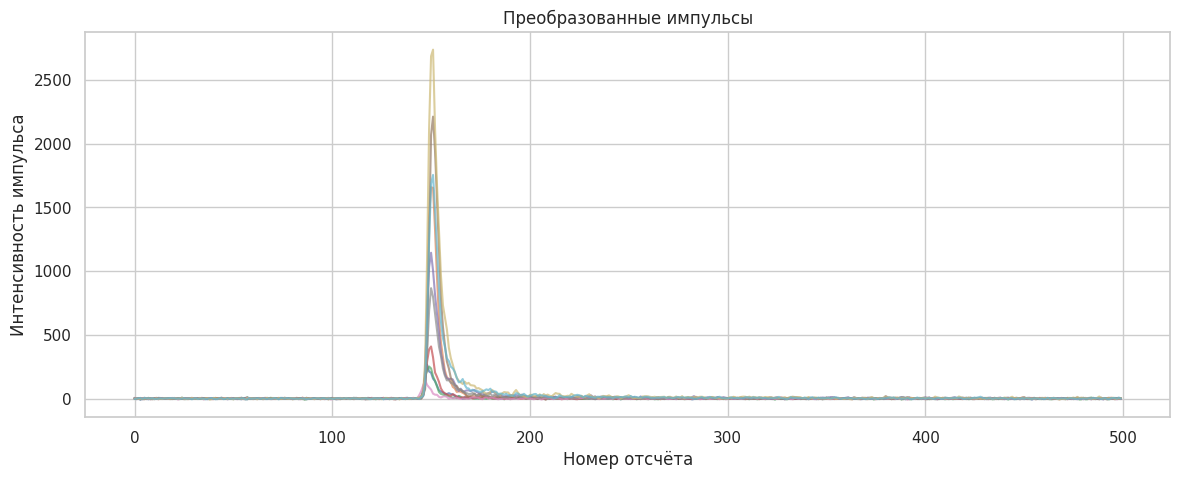

In [19]:
baseline_window = 100
baseline = signals_df.iloc[:, :baseline_window].mean(axis=1)

pulse_df = signals_df.rsub(baseline, axis=0)
positive_pulse_df = pulse_df.clip(lower=0)

plt.figure(figsize=(14, 5))

for idx in sample_indices:
    plt.plot(pulse_df.loc[idx].values, alpha=0.7)

plt.title("Преобразованные импульсы")
plt.xlabel("Номер отсчёта")
plt.ylabel("Интенсивность импульса")
plt.show()


In [20]:
features_df = pd.DataFrame(index=df.index)

features_df["baseline"] = baseline
features_df["min_signal"] = signals_df.min(axis=1)
features_df["max_pulse"] = pulse_df.max(axis=1)
features_df["argmax_pulse"] = pulse_df.values.argmax(axis=1)
features_df["pulse_area"] = positive_pulse_df.sum(axis=1)
features_df["pulse_energy"] = (positive_pulse_df ** 2).sum(axis=1)

threshold_ratio = 0.10
thresholds = features_df["max_pulse"] * threshold_ratio
pulse_widths = []

for idx in pulse_df.index:
    pulse_values = positive_pulse_df.loc[idx].values
    pulse_widths.append(np.sum(pulse_values > thresholds.loc[idx]))

features_df["pulse_width"] = pulse_widths

recovery_ratio = 0.05
recovery_times = []

for idx in pulse_df.index:
    pulse_values = positive_pulse_df.loc[idx].values
    max_position = int(features_df.loc[idx, "argmax_pulse"])
    max_value = features_df.loc[idx, "max_pulse"]
    recovery_threshold = max_value * recovery_ratio
    tail_values = pulse_values[max_position:]
    recovered_positions = np.where(tail_values <= recovery_threshold)[0]

    if len(recovered_positions) > 0:
        recovery_time = recovered_positions[0]
    else:
        recovery_time = len(tail_values)

    recovery_times.append(recovery_time)

features_df["recovery_time"] = recovery_times
features_df["pulse_mean"] = positive_pulse_df.mean(axis=1)
features_df["pulse_std"] = positive_pulse_df.std(axis=1)
features_df["pulse_median"] = positive_pulse_df.median(axis=1)
features_df["pulse_skew"] = skew(positive_pulse_df, axis=1)
features_df["pulse_kurtosis"] = kurtosis(positive_pulse_df, axis=1)

informative_service_columns = [
    column for column in service_columns
    if column not in constant_columns
]

for column in informative_service_columns:
    features_df[f"service_{column}"] = df[column]

features_df.head()


,baseline,min_signal,max_pulse,argmax_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_mean,pulse_std,pulse_median,pulse_skew,pulse_kurtosis,service_0,service_1,service_2
0,14821.13,14291,530.13,149,4983.28,1.106661e+06,14,15,9.96656,46.024183,1.13,8.262674,73.928209,2890276,357,113
1,14822.47,12921,1901.47,150,12655.80,1.360624e+07,11,11,25.31160,163.171872,2.47,8.942117,85.015075,4928764,740,359
2,14821.92,12264,2557.92,151,17264.16,2.591893e+07,12,13,34.52832,225.271278,1.92,8.873357,83.508607,9630204,162,499
3,14822.76,14258,564.76,149,5015.84,1.295659e+06,12,12,10.03168,49.956721,1.76,8.454615,76.946673,15798632,841,123
4,14821.43,13028,1793.43,150,12013.03,1.249674e+07,12,11,24.02606,156.413441,1.43,8.869941,83.154322,20637296,412,348


In [21]:
features_df.describe().T


,count,mean,std,min,25%,50%,75%,max
baseline,23479.0,1.482297e+04,8.204018e-01,1.481862e+04,1.482242e+04,1.482296e+04,1.482352e+04,1.482634e+04
min_signal,23479.0,1.298786e+04,2.389309e+03,0.000000e+00,1.250800e+04,1.401000e+04,1.451500e+04,1.471900e+04
max_pulse,23479.0,1.835103e+03,2.389301e+03,1.042300e+02,3.082200e+02,8.127200e+02,2.315270e+03,1.482482e+04
argmax_pulse,23479.0,1.496286e+02,2.489996e+00,1.450000e+02,1.490000e+02,1.500000e+02,1.510000e+02,4.720000e+02
pulse_area,23479.0,1.351527e+04,1.602687e+04,1.087400e+03,2.884815e+03,6.628800e+03,1.761989e+04,1.132773e+05
pulse_energy,23479.0,3.569897e+07,8.928643e+07,5.133089e+04,3.938410e+05,2.674202e+06,2.153665e+07,1.125854e+09
pulse_width,23479.0,1.339861e+01,2.701102e+00,6.000000e+00,1.100000e+01,1.300000e+01,1.500000e+01,2.900000e+01
recovery_time,23479.0,1.434584e+01,3.763347e+00,7.000000e+00,1.100000e+01,1.400000e+01,1.700000e+01,3.000000e+01
pulse_mean,23479.0,2.703054e+01,3.205373e+01,2.174800e+00,5.769630e+00,1.325760e+01,3.523977e+01,2.265545e+02
pulse_std,23479.0,1.615199e+02,2.090278e+02,9.869371e+00,2.750227e+01,7.197936e+01,2.045449e+02,1.484854e+03


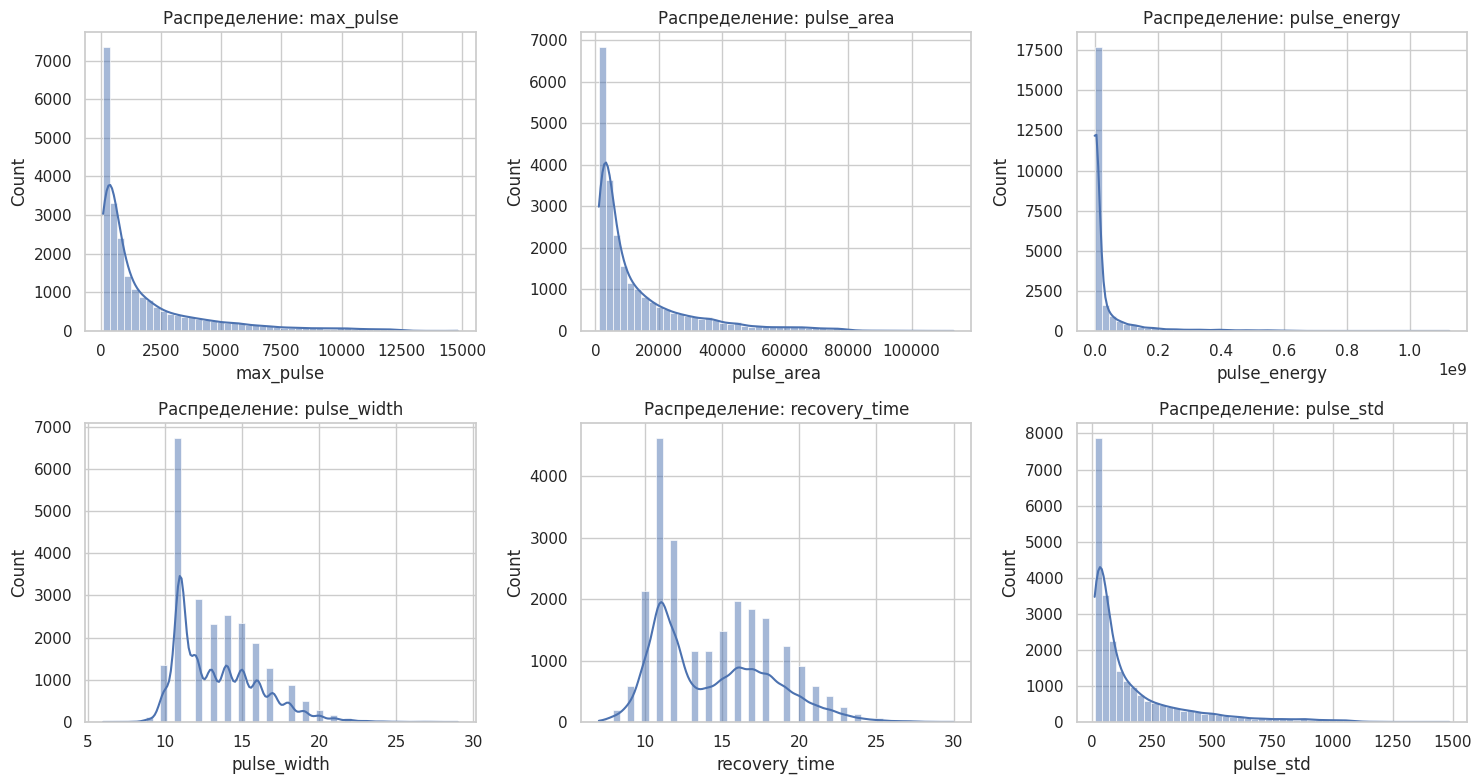

In [22]:
important_features = [
    "max_pulse",
    "pulse_area",
    "pulse_energy",
    "pulse_width",
    "recovery_time",
    "pulse_std",
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

for idx, feature in enumerate(important_features):
    row = idx // 3
    col = idx % 3

    sns.histplot(
        data=features_df,
        x=feature,
        bins=50,
        kde=True,
        ax=axes[row, col],
    )
    axes[row, col].set_title(f"Распределение: {feature}")

plt.tight_layout()
plt.show()


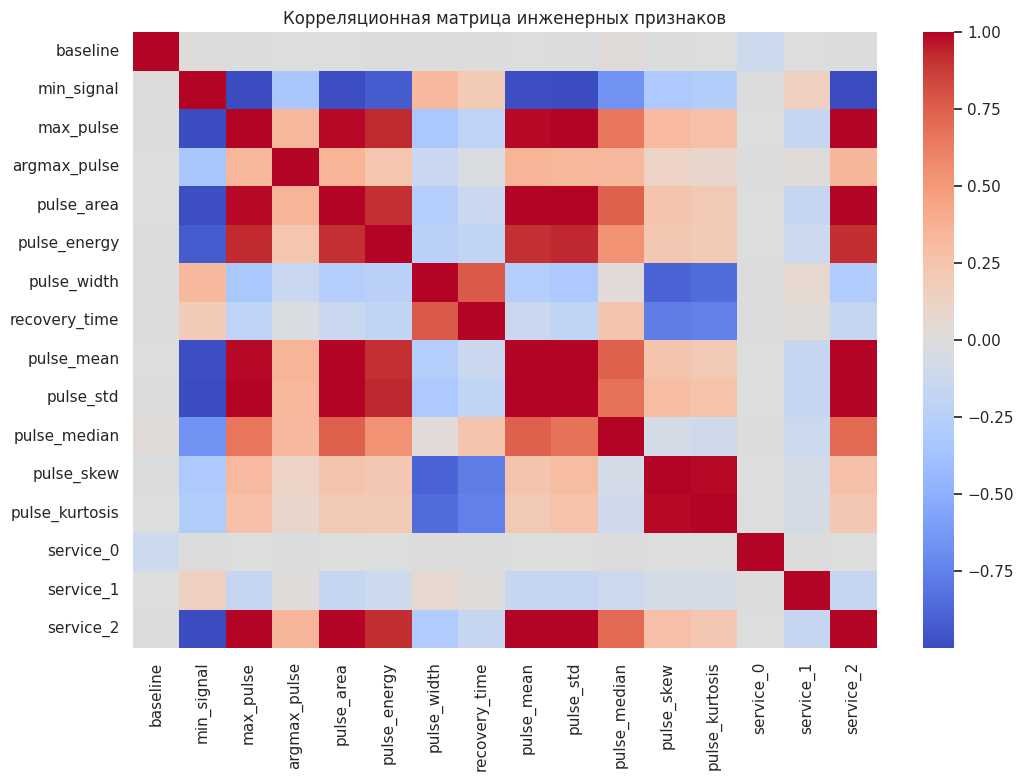

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    features_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Корреляционная матрица инженерных признаков")

plt.show()


### Вывод по шагу 5

После преобразования `baseline - signal` импульсы стали положительными, что упростило расчёт физических признаков. Распределения `max_pulse`, `pulse_area`, `pulse_energy` и `pulse_std` имеют выраженную правостороннюю асимметрию: большая часть событий имеет относительно небольшую интенсивность, но присутствуют редкие сильные импульсы. Признаки `pulse_width` и `recovery_time` имеют несколько локальных пиков, что может отражать различия в форме и длительности сигналов.

Корреляционная матрица показывает сильную связь между амплитудой, площадью, энергией и стандартным отклонением импульса. Это означает, что инженерные признаки физически осмысленны, но частично избыточны. Поэтому на следующем этапе применяется PCA.


## Шаг 6. Снижение размерности

PCA используется для уменьшения размерности инженерных признаков, анализа избыточности и визуализации структуры данных.


In [24]:
constant_feature_columns = features_df.columns[
    features_df.nunique() <= 1
].tolist()

features_df_clean = features_df.drop(columns=constant_feature_columns)

feature_scaler = RobustScaler()
features_scaled = feature_scaler.fit_transform(features_df_clean)

features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_df_clean.columns,
    index=features_df_clean.index,
)

constant_feature_columns


[]

In [25]:
pca_full = PCA(random_state=RANDOM_STATE)
features_pca_full = pca_full.fit_transform(features_scaled_df)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_variance_df = pd.DataFrame(
    {
        "component": np.arange(1, len(explained_variance) + 1),
        "explained_variance": explained_variance,
        "cumulative_variance": cumulative_variance,
    }
)

pca_variance_df.head(10)


,component,explained_variance,cumulative_variance
0,1,0.821974,0.821974
1,2,0.053728,0.875702
2,3,0.046672,0.922374
3,4,0.026547,0.948921
4,5,0.018392,0.967313
5,6,0.010740,0.978053
6,7,0.010555,0.988608
7,8,0.005465,0.994073
8,9,0.003441,0.997515
9,10,0.002217,0.999731


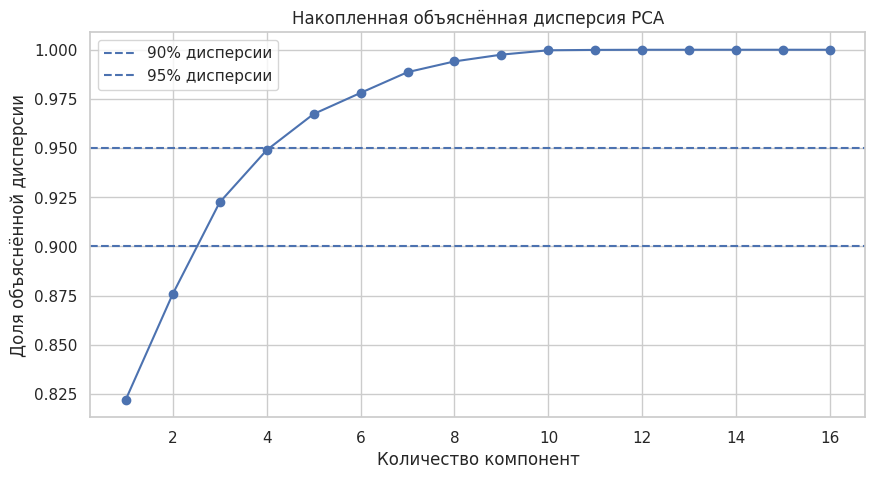

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(
    pca_variance_df["component"],
    pca_variance_df["cumulative_variance"],
    marker="o",
)
plt.axhline(y=0.90, linestyle="--", label="90% дисперсии")
plt.axhline(y=0.95, linestyle="--", label="95% дисперсии")
plt.title("Накопленная объяснённая дисперсия PCA")
plt.xlabel("Количество компонент")
plt.ylabel("Доля объяснённой дисперсии")
plt.legend()
plt.show()


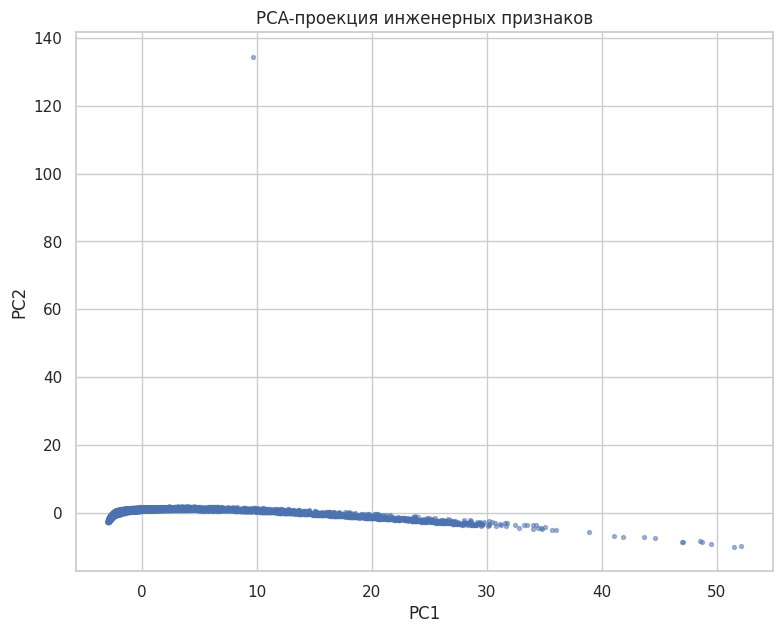

In [27]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
features_pca_2d = pca_2d.fit_transform(features_scaled_df)

pca_2d_df = pd.DataFrame(
    features_pca_2d,
    columns=["PC1", "PC2"],
    index=features_scaled_df.index,
)

plt.figure(figsize=(9, 7))
plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    s=8,
    alpha=0.5,
)
plt.title("PCA-проекция инженерных признаков")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Вывод по шагу 6

Из инженерных признаков был удалён константный признак `service_3`. Первая главная компонента объясняет около 82% дисперсии, а первые две компоненты — около 87.6%. Для сохранения более 95% дисперсии достаточно примерно пяти компонент. Это подтверждает высокую коррелированность инженерных признаков.

PCA-проекция показывает вытянутую структуру данных: большинство объектов расположены вдоль одной основной оси, что может отражать изменение силы или энергии зарегистрированного события. Также присутствуют отдельные выбросы, потенциально соответствующие аномальным сигналам.


## Шаг 7. Базовые модели кластеризации

Проверим две базовые модели: K-Means и Gaussian Mixture Model. Для сравнения используются внутренние метрики кластеризации.


In [28]:
def evaluate_clustering(data, labels, model_name):
    """Возвращает основные метрики качества кластеризации."""
    return {
        "model": model_name,
        "n_clusters": len(np.unique(labels)),
        "silhouette": silhouette_score(data, labels),
        "davies_bouldin": davies_bouldin_score(data, labels),
        "calinski_harabasz": calinski_harabasz_score(data, labels),
    }


In [29]:
kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=20,
    random_state=RANDOM_STATE,
)

kmeans_labels = kmeans.fit_predict(features_scaled_df)

kmeans_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=kmeans_labels,
    model_name="KMeans_features",
)

kmeans_metrics


{'model': 'KMeans_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.5693406335508542),
 'davies_bouldin': np.float64(0.6624569477624739),
 'calinski_harabasz': np.float64(31801.364903294972)}

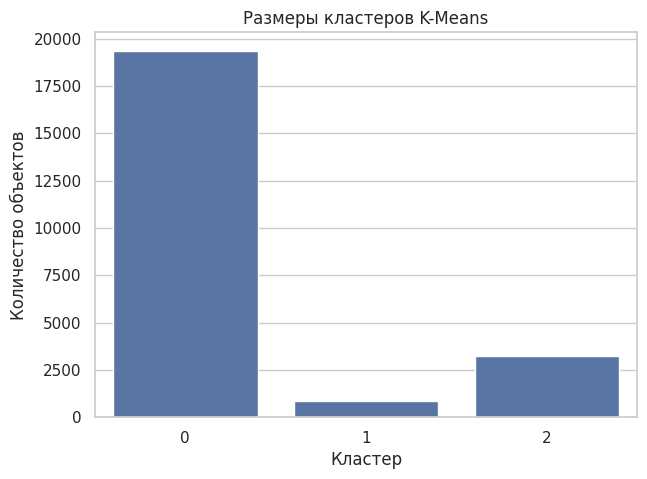

In [30]:
kmeans_cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=kmeans_cluster_counts.index,
    y=kmeans_cluster_counts.values,
)
plt.title("Размеры кластеров K-Means")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")
plt.show()


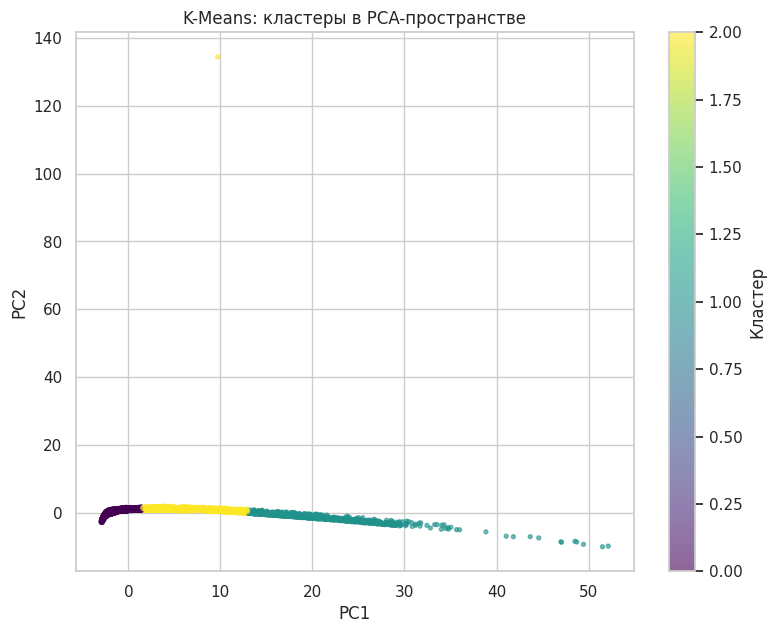

In [31]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    pca_2d_df["PC1"],
    pca_2d_df["PC2"],
    c=kmeans_labels,
    s=8,
    alpha=0.6,
    cmap="viridis",
)
plt.title("K-Means: кластеры в PCA-пространстве")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Кластер")
plt.show()


In [32]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=RANDOM_STATE,
)

gmm_labels = gmm.fit_predict(features_scaled_df)

gmm_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=gmm_labels,
    model_name="GMM_features",
)

gmm_metrics


{'model': 'GMM_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.05650697951718361),
 'davies_bouldin': np.float64(2.0134813632505963),
 'calinski_harabasz': np.float64(7297.93999502201)}

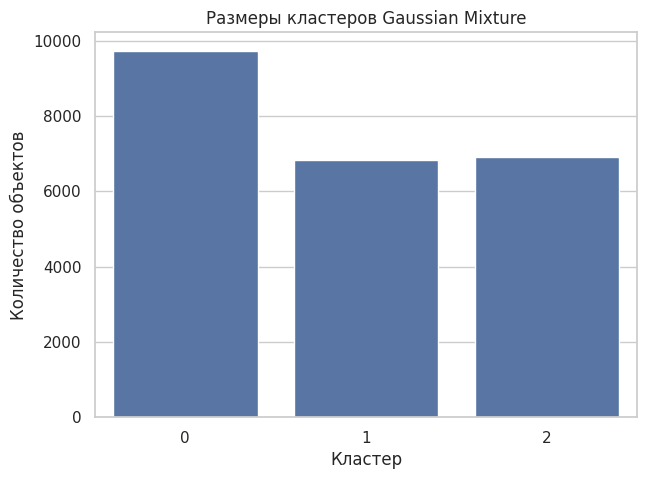

In [33]:
gmm_cluster_counts = pd.Series(gmm_labels).value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=gmm_cluster_counts.index,
    y=gmm_cluster_counts.values,
)
plt.title("Размеры кластеров Gaussian Mixture")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")
plt.show()


In [34]:
base_results = pd.DataFrame([kmeans_metrics, gmm_metrics])
base_results


,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,KMeans_features,3,0.569341,0.662457,31801.364903
1,GMM_features,3,0.056507,2.013481,7297.939995


### Вывод по шагу 7

K-Means показал существенно лучшие внутренние метрики, чем базовая GMM с `covariance_type="full"`. Для K-Means получен Silhouette Score около 0.57, что указывает на достаточно выраженную структуру кластеров. Разбиение получилось неравномерным: один крупный кластер, один средний и один малый. Такая структура согласуется с постановкой задачи, где один из кластеров может соответствовать аномальным или трудно классифицируемым сигналам.


## Шаг 8. Продвинутые модели кластеризации

Проверим Agglomerative Clustering и DBSCAN. Первый алгоритм позволяет оценить устойчивость структуры при иерархическом подходе, второй — обнаружить шумовые объекты и выбросы.


In [35]:
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward",
)

agg_labels = agg_model.fit_predict(features_scaled_df)

agg_metrics = evaluate_clustering(
    data=features_scaled_df,
    labels=agg_labels,
    model_name="Agglomerative_features",
)

agg_metrics


{'model': 'Agglomerative_features',
 'n_clusters': 3,
 'silhouette': np.float64(0.45271791382365395),
 'davies_bouldin': np.float64(0.8284894633829119),
 'calinski_harabasz': np.float64(28365.71344252198)}

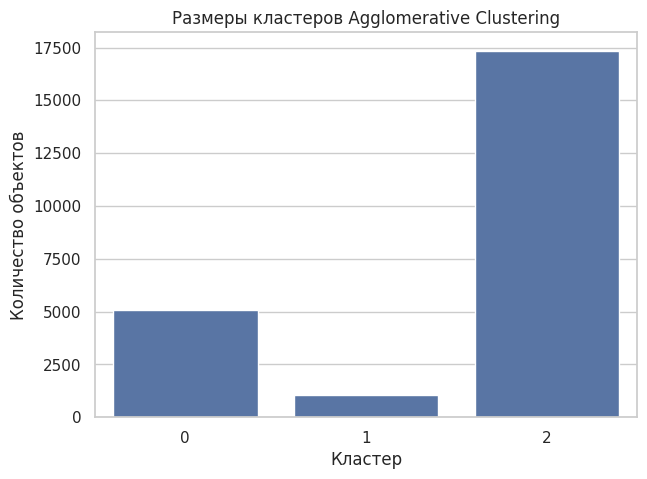

In [36]:
agg_cluster_counts = pd.Series(agg_labels).value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=agg_cluster_counts.index,
    y=agg_cluster_counts.values,
)
plt.title("Размеры кластеров Agglomerative Clustering")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")
plt.show()


In [37]:
pca_for_dbscan = PCA(n_components=5, random_state=RANDOM_STATE)
features_pca_5d = pca_for_dbscan.fit_transform(features_scaled_df)

dbscan_model = DBSCAN(eps=0.8, min_samples=20)
dbscan_labels = dbscan_model.fit_predict(features_pca_5d)

dbscan_cluster_counts = pd.Series(dbscan_labels).value_counts().sort_index()
dbscan_cluster_counts


,count
-1,437
0,22907
1,44
2,62
3,29


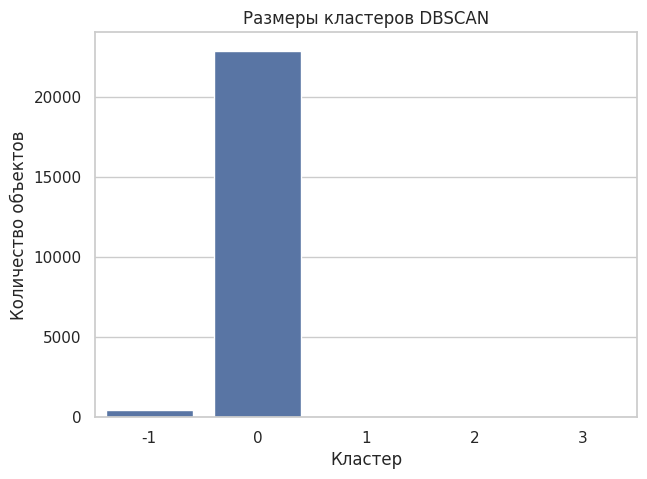

In [38]:
plt.figure(figsize=(7, 5))
sns.barplot(
    x=dbscan_cluster_counts.index,
    y=dbscan_cluster_counts.values,
)
plt.title("Размеры кластеров DBSCAN")
plt.xlabel("Кластер")
plt.ylabel("Количество объектов")
plt.show()


In [39]:
valid_dbscan_labels = dbscan_labels[dbscan_labels != -1]
n_dbscan_clusters = len(set(valid_dbscan_labels))

if n_dbscan_clusters > 1:
    dbscan_metrics = evaluate_clustering(
        data=features_pca_5d,
        labels=dbscan_labels,
        model_name="DBSCAN_PCA_5D",
    )
else:
    dbscan_metrics = {
        "model": "DBSCAN_PCA_5D",
        "n_clusters": n_dbscan_clusters,
        "silhouette": np.nan,
        "davies_bouldin": np.nan,
        "calinski_harabasz": np.nan,
    }

dbscan_metrics


{'model': 'DBSCAN_PCA_5D',
 'n_clusters': 5,
 'silhouette': np.float64(0.6110936399348056),
 'davies_bouldin': np.float64(1.4237048997311563),
 'calinski_harabasz': np.float64(3095.8787292977563)}

### Вывод по шагу 8

Agglomerative Clustering также выделил три неравномерных кластера и показал приемлемое качество, но уступил K-Means по Silhouette Score и Davies-Bouldin Index. DBSCAN выделил один основной кластер, несколько малых групп и шумовые объекты. Это подтверждает наличие небольшого количества потенциально аномальных сигналов. Однако DBSCAN не подходит как итоговая модель для Kaggle, так как требуется ровно три кластера с номерами 0, 1 и 2.


## Шаг 9. Подбор гиперпараметров

Для повышения качества и обоснования выбора модели сравним разные значения `k` для K-Means и разные типы ковариационной матрицы для GMM.


In [40]:
kmeans_results = []

for n_clusters in range(2, 9):
    model = KMeans(
        n_clusters=n_clusters,
        init="k-means++",
        n_init=30,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(features_scaled_df)

    result = evaluate_clustering(
        data=features_scaled_df,
        labels=labels,
        model_name=f"KMeans_k_{n_clusters}",
    )
    result["inertia"] = model.inertia_
    kmeans_results.append(result)

kmeans_results_df = pd.DataFrame(kmeans_results)
kmeans_results_df


,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,inertia
0,KMeans_k_2,2,0.746335,0.543872,32764.499064,301650.590375
1,KMeans_k_3,3,0.569341,0.662457,31801.364903,194818.634628
2,KMeans_k_4,4,0.414077,0.813825,27413.654497,160466.245271
3,KMeans_k_5,5,0.412717,0.652122,25625.934271,134652.014477
4,KMeans_k_6,6,0.306721,0.820807,26043.917068,110365.730160
5,KMeans_k_7,7,0.307785,0.816421,26624.014255,92577.489053
6,KMeans_k_8,8,0.300163,0.839115,26030.169720,82461.919288


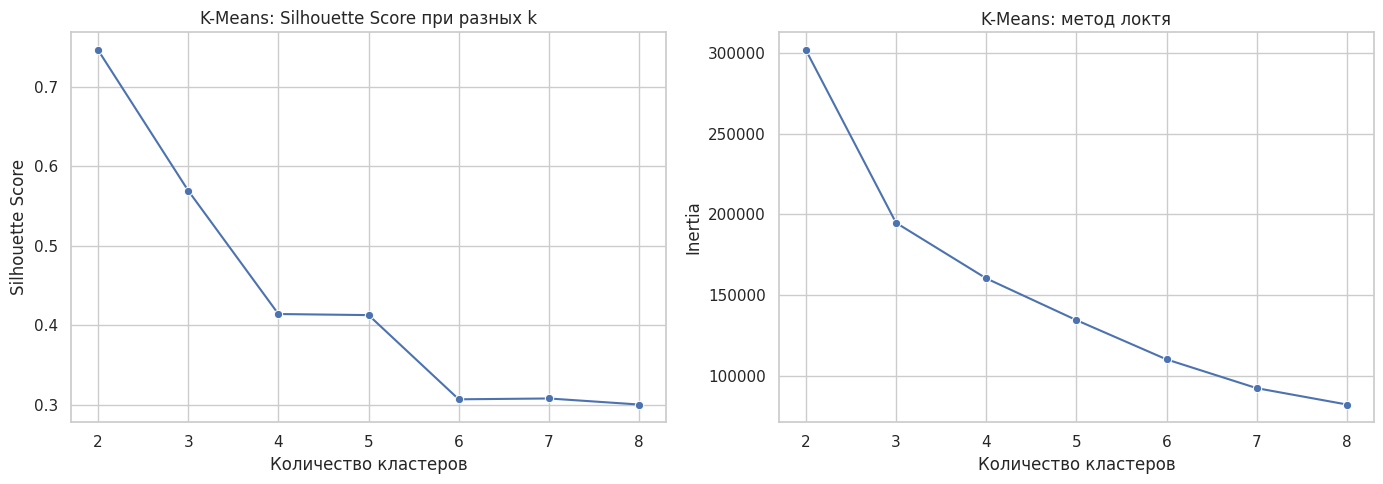

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

sns.lineplot(
    data=kmeans_results_df,
    x="n_clusters",
    y="silhouette",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("K-Means: Silhouette Score при разных k")
axes[0].set_xlabel("Количество кластеров")
axes[0].set_ylabel("Silhouette Score")

sns.lineplot(
    data=kmeans_results_df,
    x="n_clusters",
    y="inertia",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("K-Means: метод локтя")
axes[1].set_xlabel("Количество кластеров")
axes[1].set_ylabel("Inertia")

plt.tight_layout()
plt.show()


In [42]:
gmm_results = []

for covariance_type in ["full", "tied", "diag", "spherical"]:
    model = GaussianMixture(
        n_components=3,
        covariance_type=covariance_type,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(features_scaled_df)

    result = evaluate_clustering(
        data=features_scaled_df,
        labels=labels,
        model_name=f"GMM_{covariance_type}",
    )
    result["bic"] = model.bic(features_scaled_df)
    result["aic"] = model.aic(features_scaled_df)
    gmm_results.append(result)

gmm_results_df = pd.DataFrame(gmm_results)
gmm_results_df


,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,bic,aic
0,GMM_full,3,0.056507,2.013481,7297.939995,-867851.775415,-871545.024066
1,GMM_tied,3,0.561880,0.670786,30810.642231,-492729.488150,-494229.366423
2,GMM_diag,3,0.050330,2.131914,6832.830612,382390.426025,381600.167580
3,GMM_spherical,3,0.453104,0.813800,26481.621737,709474.696824,709047.312155


In [43]:
all_results = pd.DataFrame(
    [
        kmeans_metrics,
        gmm_metrics,
        agg_metrics,
        dbscan_metrics,
    ]
)

all_results = pd.concat(
    [
        all_results,
        kmeans_results_df,
        gmm_results_df,
    ],
    ignore_index=True,
)

all_results.sort_values(by="silhouette", ascending=False)


,model,n_clusters,silhouette,davies_bouldin,calinski_harabasz,inertia,bic,aic
4,KMeans_k_2,2,0.746335,0.543872,32764.499064,301650.590375,NaN,NaN
3,DBSCAN_PCA_5D,5,0.611094,1.423705,3095.878729,NaN,NaN,NaN
0,KMeans_features,3,0.569341,0.662457,31801.364903,NaN,NaN,NaN
5,KMeans_k_3,3,0.569341,0.662457,31801.364903,194818.634628,NaN,NaN
12,GMM_tied,3,0.561880,0.670786,30810.642231,NaN,-492729.488150,-494229.366423
14,GMM_spherical,3,0.453104,0.813800,26481.621737,NaN,709474.696824,709047.312155
2,Agglomerative_features,3,0.452718,0.828489,28365.713443,NaN,NaN,NaN
6,KMeans_k_4,4,0.414077,0.813825,27413.654497,160466.245271,NaN,NaN
7,KMeans_k_5,5,0.412717,0.652122,25625.934271,134652.014477,NaN,NaN
9,KMeans_k_7,7,0.307785,0.816421,26624.014255,92577.489053,NaN,NaN


### Вывод по шагу 9

Максимальный Silhouette Score для K-Means достигается при `k=2`, однако по условию соревнования необходимо получить три кластера. При `k=3` K-Means сохраняет высокое качество и полностью соответствует формату задачи. Среди вариантов GMM лучший результат показала модель `GMM_tied`, близкая к K-Means по метрикам, однако K-Means остаётся немного лучше и проще интерпретируется. Поэтому итоговой моделью выбрана K-Means с тремя кластерами.


## Шаг 10. Выбор лучшей модели и интерпретация кластеров

В качестве итоговой модели используется K-Means с тремя кластерами на масштабированных инженерных признаках.


In [44]:
final_model = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=50,
    random_state=RANDOM_STATE,
)

final_labels = final_model.fit_predict(features_scaled_df)

features_with_clusters = features_df_clean.copy()
features_with_clusters["cluster_raw"] = final_labels

features_with_clusters["cluster_raw"].value_counts().sort_index()


,count
cluster_raw,
0,19363
1,879
2,3237


In [45]:
important_profile_columns = [
    "max_pulse",
    "pulse_area",
    "pulse_energy",
    "pulse_width",
    "recovery_time",
    "pulse_std",
]

cluster_profile = features_with_clusters.groupby("cluster_raw").mean()
cluster_sizes = features_with_clusters["cluster_raw"].value_counts().sort_index()

cluster_summary = cluster_profile[important_profile_columns].copy()
cluster_summary["cluster_size"] = cluster_sizes

cluster_summary


,max_pulse,pulse_area,pulse_energy,pulse_width,recovery_time,pulse_std,cluster_size
cluster_raw,,,,,,,
0,900.791799,7281.347326,5.986997e+06,13.730001,14.683314,79.958862,19363
1,10173.713902,67939.206576,4.153345e+08,11.417520,11.853242,892.870548,879
2,5159.612172,36026.481952,1.103401e+08,11.954279,13.004016,450.803009,3237


In [46]:
anomaly_cluster = cluster_sizes.idxmin()
normal_clusters = [
    cluster for cluster in cluster_sizes.index
    if cluster != anomaly_cluster
]

normal_clusters_sorted = (
    cluster_profile
    .loc[normal_clusters]
    .sort_values("max_pulse")
    .index
    .tolist()
)

cluster_mapping = {
    normal_clusters_sorted[0]: 0,
    normal_clusters_sorted[1]: 1,
    anomaly_cluster: 2,
}

features_with_clusters["cluster"] = (
    features_with_clusters["cluster_raw"]
    .map(cluster_mapping)
)

features_with_clusters["cluster"].value_counts().sort_index()


,count
cluster,
0,19363
1,3237
2,879


### Вывод по шагу 10

Итоговая модель K-Means выделяет три группы сигналов, различающиеся по амплитуде, площади, энергии и ширине импульса. Малочисленный кластер интерпретируется как группа потенциально аномальных или трудно классифицируемых сигналов. Номера кластеров были переупорядочены так, чтобы кластеры 0 и 1 соответствовали двум основным типам сигналов, а кластер 2 — малой группе нестандартных событий.


## Шаг 11. Формирование Kaggle Submission

Файл для Kaggle должен содержать две колонки: `index` и `cluster`.


In [47]:
submission = pd.DataFrame(
    {
        "index": df.index,
        "cluster": features_with_clusters["cluster"].values,
    }
)

submission.to_csv("submission.csv", index=False)
submission.head()


,index,cluster
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [48]:
submission["cluster"].value_counts().sort_index()


,count
cluster,
0,19363
1,3237
2,879


In [49]:
for idx, permutation in enumerate(permutations([0, 1, 2])):
    mapping = {
        0: permutation[0],
        1: permutation[1],
        2: permutation[2],
    }

    alternative_submission = pd.DataFrame(
        {
            "index": df.index,
            "cluster": pd.Series(final_labels).map(mapping),
        }
    )

    alternative_submission.to_csv(
        f"submission_kmeans_perm_{idx}.csv",
        index=False,
    )


### Вывод по шагу 11

Сформирован основной файл `submission.csv` в формате Kaggle. Дополнительно сохранены шесть файлов с разными перестановками номеров кластеров. Это важно для задач обучения без учителя: номера кластеров условны, поэтому разные варианты перенумерации могут давать разный результат на скрытой разметке Kaggle.


## Шаг 12. Анализ результата Kaggle

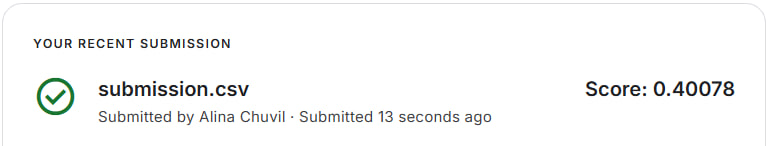

Для итогового решения была использована модель K-Means с тремя кластерами на инженерных признаках.

Полученный результат на Kaggle составил **0.40078** по метрике Accuracy.

Несмотря на достаточно хорошие внутренние метрики кластеризации, результат на Kaggle оказался ниже целевого уровня. Возможные причины:

- инженерные признаки описывают сигнал компактно, но теряют часть информации о полной форме импульса;
- выбранная схема перенумерации кластеров может не совпадать со скрытой разметкой;
- истинное разделение гамма-квантов и нейтронов может зависеть от более тонких различий формы сигнала, чем амплитуда, площадь и энергия.

Перспективные направления улучшения:

- перебор всех перестановок номеров кластеров;
- кластеризация по PCA-компонентам, построенным на 500 отсчётах сигнала;
- применение Spectral Clustering и HDBSCAN;
- более точное выделение области импульса и расчёт признаков спада сигнала.

**скриншот результата Kaggle:**   
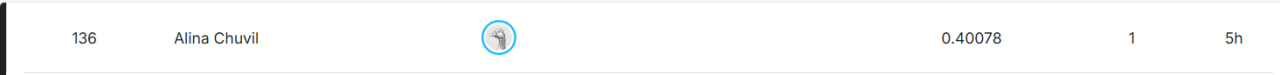



# Итоговые выводы

В ходе работы была решена задача кластеризации сцинтилляционных сигналов методами машинного обучения без учителя.

Были выполнены:

- загрузка и первичное изучение данных;
- разведочный анализ сигналов;
- предобработка и масштабирование признаков;
- извлечение физических характеристик импульса;
- снижение размерности методом PCA;
- сравнение нескольких алгоритмов кластеризации;
- подбор гиперпараметров;
- формирование submission-файла для Kaggle.

EDA показал, что сигналы имеют выраженную импульсную структуру: стабильный baseline, резкий импульс и восстановление. Максимальная изменчивость сосредоточена в области импульса, поэтому Feature Engineering был направлен на описание его амплитуды, площади, энергии, ширины и времени восстановления.

Среди протестированных моделей лучшие внутренние метрики показали K-Means и Gaussian Mixture с `covariance_type="tied"`. Итоговой моделью была выбрана K-Means с тремя кластерами, так как она соответствует условию задачи, обладает хорошими внутренними метриками и даёт интерпретируемое разбиение.

Результат на Kaggle составил **0.40078**. Это решение является воспроизводимой базовой версией проекта. Для повышения качества дальнейшая работа должна быть направлена на использование полной формы сигнала и более тонких признаков временного спада импульса.
